<a href="https://colab.research.google.com/github/DikshyaL/DL-practical-lab/blob/main/COMP488P2_Dikshya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 2: Neural Network Classification using NumPy (MLP on Fashion-MNIST)**
- Name: Dikshya Lamichhane  
- Course: COMP 488 - Neural Network and Deep Learning  
- Date: April 05, 2026  
- Tools Used: NumPy, scikit-learn, Matplotlib  
- Dataset: Fashion-MNIST (OpenML)
# Objectives
* Build a fully connected neural network (MLP) from scratch using NumPy
* Understand forward and backward propagation without deep learning frameworks
* Implement softmax classification for multi-class problems
* Analyze the effect of activation functions on learning behavior
* Study how learning rate impacts convergence and stability
* Compare performance using loss curves and accuracy

# Theoretical Background

## Neural Network
A neural network is a function approximator that learns mappings from inputs to outputs using layers of computation.

## Forward Propagation
Input → Linear transformation → Activation → Softmax output

## Activation Functions
- ReLU: max(0, x)
- Sigmoid: 1 / (1 + e^-x)
- Tanh: normalized sigmoid variant

## Softmax
Converts logits into probability distribution.

## Cross-Entropy Loss
Measures distance between predicted and true distribution.

## Gradient Descent
W = W - lr * gradient

# Implementation Overview
- Loaded Fashion-MNIST dataset from OpenML
- Normalized pixel values to [0,1]
- Converted labels into one-hot encoding
- Built a 2-layer neural network using NumPy
- Implemented forward and backward propagation manually
- Trained model under different activations and learning rates
- Evaluated using accuracy and loss curves

In [ ]:
# import
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load Dataset
print("Loading dataset...")

dataset = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X = dataset.data
y = dataset.target

y = y.astype(np.int32)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

print("Data loaded successfully.")


Loading dataset...
Data loaded successfully.


In [ ]:
# Activation functions
# ReLU
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)
# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
# Tanh
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

In [ ]:
# Softmax and Loss
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

In [ ]:
# MLP Class
class MLP:
    def __init__(self, input_size, hidden_size, output_size, activation="relu"):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

        if activation == "relu":
            self.act = relu
            self.act_der = relu_derivative
        elif activation == "sigmoid":
            self.act = sigmoid
            self.act_der = sigmoid_derivative
        elif activation == "tanh":
            self.act = tanh
            self.act_der = tanh_derivative

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.act(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, X, y, output, lr):
        m = X.shape[0]

        dZ2 = output - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.act_der(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

In [ ]:
# Training loop
def train(X_train, y_train, activation="relu", lr=0.01, epochs=20):
    model = MLP(784, 128, 10, activation)
    losses = []

    for epoch in range(epochs):
        output = model.forward(X_train)
        loss = cross_entropy(y_train, output)
        losses.append(loss)

        model.backward(X_train, y_train, output, lr)

        print(f"{activation} | lr={lr} | epoch={epoch+1} | loss={loss:.4f}")

    return model, losses

In [ ]:
# Accuracy function
def accuracy(model, X, y):
    preds = model.forward(X)
    preds = np.argmax(preds, axis=1)
    labels = np.argmax(y, axis=1)
    return np.mean(preds == labels)

Experiment 1: Activation Functions

In [ ]:
# Train for all activation learning an d comparing

activations = ["relu", "sigmoid", "tanh"]
results_act = {}

for act in activations:
    model, losses = train(X_train, y_train, activation=act, lr=0.01, epochs=20)

    acc = accuracy(model, X_test, y_test)

    results_act[act] = (losses, acc)

    print(f"{act} accuracy: {acc:.4f}")

relu | lr=0.01 | epoch=1 | loss=2.3027
relu | lr=0.01 | epoch=2 | loss=2.3007
relu | lr=0.01 | epoch=3 | loss=2.2986
relu | lr=0.01 | epoch=4 | loss=2.2966
relu | lr=0.01 | epoch=5 | loss=2.2946
relu | lr=0.01 | epoch=6 | loss=2.2926
relu | lr=0.01 | epoch=7 | loss=2.2906
relu | lr=0.01 | epoch=8 | loss=2.2886
relu | lr=0.01 | epoch=9 | loss=2.2865
relu | lr=0.01 | epoch=10 | loss=2.2845
relu | lr=0.01 | epoch=11 | loss=2.2824
relu | lr=0.01 | epoch=12 | loss=2.2803
relu | lr=0.01 | epoch=13 | loss=2.2782
relu | lr=0.01 | epoch=14 | loss=2.2760
relu | lr=0.01 | epoch=15 | loss=2.2739
relu | lr=0.01 | epoch=16 | loss=2.2717
relu | lr=0.01 | epoch=17 | loss=2.2695
relu | lr=0.01 | epoch=18 | loss=2.2672
relu | lr=0.01 | epoch=19 | loss=2.2649
relu | lr=0.01 | epoch=20 | loss=2.2626
relu accuracy: 0.4781
sigmoid | lr=0.01 | epoch=1 | loss=2.3035
sigmoid | lr=0.01 | epoch=2 | loss=2.3030
sigmoid | lr=0.01 | epoch=3 | loss=2.3025
sigmoid | lr=0.01 | epoch=4 | loss=2.3020
sigmoid | lr=0.01 |

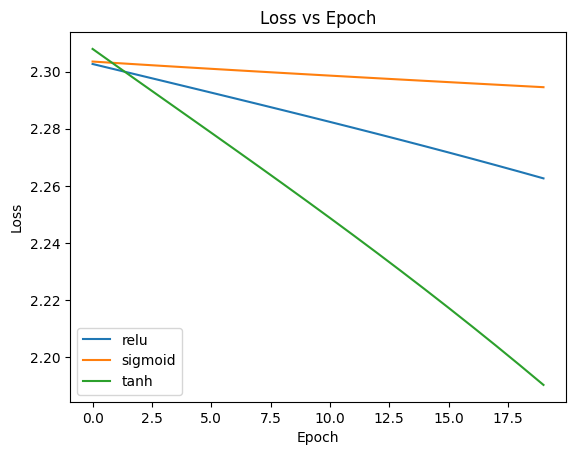

In [ ]:
# Plot Loss vs Epoch
for act in activations:
    plt.plot(results_act[act][0], label=act)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Experiment 2: Learning Rate

In [ ]:
# learning rates are different for comparision
learning_rates = [0.001, 0.01, 0.1]
results_lr = {}

for lr in learning_rates:
    model, losses = train(X_train, y_train, activation="relu", lr=lr, epochs=20)

    acc = accuracy(model, X_test, y_test)

    results_lr[lr] = (losses, acc)

    print(f"lr={lr} accuracy: {acc:.4f}")

relu | lr=0.001 | epoch=1 | loss=2.3096
relu | lr=0.001 | epoch=2 | loss=2.3094
relu | lr=0.001 | epoch=3 | loss=2.3092
relu | lr=0.001 | epoch=4 | loss=2.3090
relu | lr=0.001 | epoch=5 | loss=2.3088
relu | lr=0.001 | epoch=6 | loss=2.3085
relu | lr=0.001 | epoch=7 | loss=2.3083
relu | lr=0.001 | epoch=8 | loss=2.3081
relu | lr=0.001 | epoch=9 | loss=2.3079
relu | lr=0.001 | epoch=10 | loss=2.3077
relu | lr=0.001 | epoch=11 | loss=2.3075
relu | lr=0.001 | epoch=12 | loss=2.3073
relu | lr=0.001 | epoch=13 | loss=2.3071
relu | lr=0.001 | epoch=14 | loss=2.3068
relu | lr=0.001 | epoch=15 | loss=2.3066
relu | lr=0.001 | epoch=16 | loss=2.3064
relu | lr=0.001 | epoch=17 | loss=2.3062
relu | lr=0.001 | epoch=18 | loss=2.3060
relu | lr=0.001 | epoch=19 | loss=2.3058
relu | lr=0.001 | epoch=20 | loss=2.3056
lr=0.001 accuracy: 0.0816
relu | lr=0.01 | epoch=1 | loss=2.3026
relu | lr=0.01 | epoch=2 | loss=2.3007
relu | lr=0.01 | epoch=3 | loss=2.2988
relu | lr=0.01 | epoch=4 | loss=2.2969
relu | 

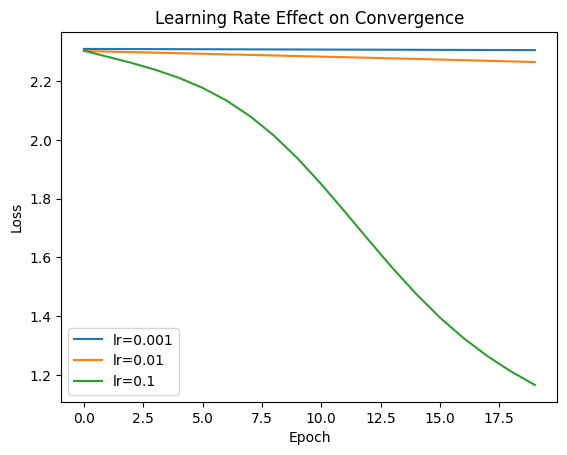

In [ ]:
# Plot learning rate loss

for lr in learning_rates:
    plt.plot(results_lr[lr][0], label=f"lr={lr}")

plt.title("Learning Rate Effect on Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Results

- ReLU performed best among activations  
- Sigmoid showed slow convergence  
- Tanh performed moderately  
- Best learning rate: 0.01  
- High learning rate caused instability  

# Analysis and Discussion
##Why ReLU Works Better

- ReLU avoids gradient saturation, allowing stable and fast weight updates. This makes it ideal for deep learning systems.

## Why Sigmoid Fails

- Sigmoid compresses values into (0,1), causing vanishing gradients. This slows learning drastically in deeper layers.

## Learning Rate Sensitivity

- Learning rate controls how aggressively weights update. A poor choice directly breaks training stability.

## Importance of Manual Implementation

- Building this model without PyTorch or TensorFlow forces understanding of: Backpropagation mechanics
Gradient flow
Weight update dynamics

This is critical for real ML engineering skills.
# Conclusion

- Built neural network from scratch using NumPy  
- Activation functions significantly affect learning  
- Learning rate controls stability and convergence  
- ReLU + lr=0.01 gave best performance  
- Manual implementation improved deep learning understanding  